# Maximizing Revenue for Taxi Cab Drivers through Payment Type Analysis

## Problem Statement

In the fast-paced taxi booking sector, making the most of revenue is essential for long-term success and driver happiness. Our goal is to use data-driven insights to maximise revenue streams for taxi drivers in order to meet this need. Our research aims to determine whether payment methods have an impact on fare pricing by focusing on the relationship between payment type and fare amount.

## Objective

This project's main goal is to run an A/B test to examine the relationship between the total fare and the method of payment. We use Python hypothesis testing and descriptive statistics to extract useful information that can help taxi drivers generate more cash. In particular, we want to find out if there is a big difference in the fares for those who pay with credit cards versus those who pay with cash.

## Research Question

Is there a relationship between total fare amount and payment type, and can we nudge customers towards payment methods that generate higher revenue for drivers, without negatively impacting customer experience?

## Importing Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

## Loading the dataset

In [2]:
df = pd.read_parquet('yellow_tripdata_2026-05.parquet')

In [3]:
df.to_csv('yellow_tripdata_2026-05', index=False)

In [4]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,2,2026-05-01 00:04:59,2026-05-01 00:32:48,1.0,7.51,1.0,N,138,37,2,35.9,6.00,0.5,0.00,0.0,1.0,45.40,0.0,2.0,0.00
1,2,2026-05-01 00:37:05,2026-05-01 00:59:47,1.0,6.14,1.0,N,138,237,1,27.5,6.00,0.5,9.56,0.0,1.0,49.81,2.5,2.0,0.75
2,1,2026-05-01 00:34:05,2026-05-01 00:54:02,1.0,2.40,1.0,N,249,232,1,19.1,4.25,0.5,3.73,0.0,1.0,28.58,2.5,0.0,0.75
3,1,2026-05-01 00:55:07,2026-05-01 01:02:43,0.0,1.20,1.0,N,232,114,1,9.3,4.25,0.5,3.00,0.0,1.0,18.05,2.5,0.0,0.75
4,7,2026-05-01 00:44:13,2026-05-01 00:44:13,2.0,0.86,1.0,N,140,237,1,7.2,0.00,0.5,2.44,0.0,1.0,14.64,2.5,0.0,0.00


In [5]:
df.shape

(4090836, 20)

In [6]:
df.dtypes

VendorID                          int32
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag               object
PULocationID                      int32
DOLocationID                      int32
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
Airport_fee                     float64
cbd_congestion_fee              float64
dtype: object

##  Feature Engineering : Trip Duration

The raw data has pickup and drop-off timestamps but no direct "how long did the trip take" column. This is calculated manually:

1. Subtract pickup time from drop-off time → gives a `timedelta`.
2. Convert that timedelta to total seconds, then divide by 60 → gives duration in **minutes**.

This `duration` feature turns out to be one of the three core numeric variables used later in the outlier cleaning and analysis.

In [7]:
df['duration']=df['tpep_dropoff_datetime']-df['tpep_pickup_datetime']

In [8]:
df['duration']=df['duration'].dt.total_seconds()/60

In [9]:
df

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,duration
0,2,2026-05-01 00:04:59,2026-05-01 00:32:48,1.0,7.51,1.0,N,138,37,2,...,6.00,0.5,0.00,0.0,1.0,45.40,0.0,2.0,0.00,27.816667
1,2,2026-05-01 00:37:05,2026-05-01 00:59:47,1.0,6.14,1.0,N,138,237,1,...,6.00,0.5,9.56,0.0,1.0,49.81,2.5,2.0,0.75,22.700000
2,1,2026-05-01 00:34:05,2026-05-01 00:54:02,1.0,2.40,1.0,N,249,232,1,...,4.25,0.5,3.73,0.0,1.0,28.58,2.5,0.0,0.75,19.950000
3,1,2026-05-01 00:55:07,2026-05-01 01:02:43,0.0,1.20,1.0,N,232,114,1,...,4.25,0.5,3.00,0.0,1.0,18.05,2.5,0.0,0.75,7.600000
4,7,2026-05-01 00:44:13,2026-05-01 00:44:13,2.0,0.86,1.0,N,140,237,1,...,0.00,0.5,2.44,0.0,1.0,14.64,2.5,0.0,0.00,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4090831,2,2026-05-31 23:35:12,2026-05-31 23:51:04,NaN,5.11,NaN,None,74,243,0,...,0.00,0.5,0.00,0.0,1.0,18.69,NaN,NaN,0.00,15.866667
4090832,1,2026-05-31 23:48:01,2026-06-01 00:05:57,NaN,8.80,NaN,None,129,130,0,...,0.00,0.5,0.00,0.0,1.0,33.48,NaN,NaN,0.00,17.933333
4090833,2,2026-05-31 23:48:50,2026-06-01 00:03:52,NaN,6.47,NaN,None,48,116,0,...,0.00,0.5,0.00,0.0,1.0,28.87,NaN,NaN,0.75,15.033333
4090834,2,2026-05-31 23:23:13,2026-05-31 23:38:35,NaN,2.94,NaN,None,113,256,0,...,0.00,0.5,0.00,0.0,1.0,22.95,NaN,NaN,0.75,15.366667


## Selecting Relevant Columns

The raw file has 20 columns (IDs, surcharges, tolls, rate codes, etc.), but the research question only needs **5**

In [10]:
df=df[['passenger_count','payment_type','fare_amount','trip_distance','duration']]

In [11]:
df

,passenger_count,payment_type,fare_amount,trip_distance,duration
0,1.0,2,35.90,7.51,27.816667
1,1.0,1,27.50,6.14,22.700000
2,1.0,1,19.10,2.40,19.950000
3,0.0,1,9.30,1.20,7.600000
4,2.0,1,7.20,0.86,0.000000
...,...,...,...,...,...
4090831,NaN,0,17.19,5.11,15.866667
4090832,NaN,0,27.98,8.80,17.933333
4090833,NaN,0,24.12,6.47,15.033333
4090834,NaN,0,18.20,2.94,15.366667


## Handling Missing Values

Checking for nulls across the 5 selected columns.

In [12]:
df.isnull().sum()

passenger_count    955371
payment_type            0
fare_amount             0
trip_distance           0
duration                0
dtype: int64

In [13]:
df['passenger_count'].isnull().mean() * 100

23.353930590226547

## Investigating *why* passenger_count is missing

Rather than dropping ~23% of the data without asking questions, the missingness is checked for a pattern is it random, or tied to something specific (like a particular payment type)?

In [14]:
# check if missingness correlated with other columns
df[df['passenger_count'].isnull()][['fare_amount','payment_type','trip_distance']].describe()

,fare_amount,payment_type,trip_distance
count,955371.000000,955371.0,955371.000000
mean,25.826020,0.0,10.095261
std,14.325213,0.0,1000.658230
min,-18.300000,0.0,0.000000
25%,16.190000,0.0,1.390000
50%,23.200000,0.0,2.630000
75%,32.210000,0.0,4.770000
max,1061.720000,0.0,307491.470000


In [15]:

df[df['passenger_count'].notnull()][['fare_amount','payment_type','trip_distance']].describe()

,fare_amount,payment_type,trip_distance
count,3.135465e+06,3.135465e+06,3.135465e+06
mean,2.019909e+01,1.148571e+00,3.388475e+00
std,2.004296e+01,4.220537e-01,6.192977e+00
min,-9.500000e+02,1.000000e+00,0.000000e+00
25%,9.300000e+00,1.000000e+00,1.000000e+00
50%,1.420000e+01,1.000000e+00,1.700000e+00
75%,2.330000e+01,1.000000e+00,3.380000e+00
max,5.525990e+03,4.000000e+00,5.071010e+03


In [16]:
df.groupby('payment_type')['trip_distance'].describe()

,count,mean,std,min,25%,50%,75%,max
payment_type,,,,,,,,
0,955371.0,10.095261,1000.658230,0.0,1.39,2.63,4.77,307491.47
1,2727585.0,3.401872,6.366593,0.0,1.01,1.72,3.39,5071.01
2,372909.0,3.344108,4.863606,0.0,0.84,1.52,3.36,277.15
3,11984.0,2.136520,4.196426,0.0,0.00,0.79,2.00,78.87
4,22987.0,3.171229,5.287642,0.0,0.38,1.20,3.06,105.30


### Note on Missing Values in passenger_count

Investigated missingness before dropping found all missing rows had `payment_type = 0` (Flex Fare), confirmed via `groupby('payment_type')` matching counts exactly (955,371 both). Since research scope covers only Card (1) vs Cash (2) payments, Flex Fare falls outside scope anyway. Filtering to `payment_type.isin([1,2])` removes these rows as a natural side effect of correct scoping not an arbitrary drop for missing data.

## Filter Payment Type

Keeping only Card (1) and Cash (2) since research question compares these two only. Other types (Flex Fare, No Charge, Dispute, Unknown, Voided) fall outside scope.

In [17]:
df = df[df['payment_type'].isin([1, 2])]
df.shape

(3100494, 5)

In [18]:
df['payment_type'].unique()

array([2, 1], dtype=int64)

In [19]:
df.isnull().sum()

passenger_count    0
payment_type       0
fare_amount        0
trip_distance      0
duration           0
dtype: int64

In [20]:
df.head()

,passenger_count,payment_type,fare_amount,trip_distance,duration
0,1.0,2,35.9,7.51,27.816667
1,1.0,1,27.5,6.14,22.700000
2,1.0,1,19.1,2.40,19.950000
3,0.0,1,9.3,1.20,7.600000
4,2.0,1,7.2,0.86,0.000000


##  Data Type Conversion

`passenger_count` is stored as a `float64` (e.g. `1.0`, `2.0`) even though it's really a whole-number count. Converting it to `int64` for cleanliness and to match `payment_type`, which is already an integer.

In [21]:
df['passenger_count'] = df['passenger_count'].astype('int64')

## Removing Duplicate Rows

In [22]:
df[df.duplicated()]

,passenger_count,payment_type,fare_amount,trip_distance,duration
517,1,2,0.0,0.01,0.083333
1453,1,2,0.0,6.94,19.900000
1648,1,1,8.6,0.90,7.183333
1932,1,1,6.5,0.60,5.033333
2076,1,1,9.3,0.98,8.366667
...,...,...,...,...,...
3135435,1,1,9.3,1.14,7.716667
3135436,1,1,13.5,0.00,15.983333
3135457,1,2,7.2,0.78,5.333333
3135460,1,1,9.3,1.26,6.616667


**Why Are There Duplicates?**
The raw dataset had 20 columns, so every ride was unique thanks to exact timestamps and location IDs. Once we dropped everything down to just 5 columns (`passenger_count`, `payment_type`, `fare_amount`, `trip_distance`, `duration`), many separate trips ended up looking identical (e.g., two different rides that both had 1 passenger, paid by card, and went the same distance for the same fare). This created over 1.2 million duplicate rows.

**Why Remove Them?**
* **No extra insight:** Identical rows do not add any new or useful information to the comparison.
* **Fair statistics:** Keeping millions of exact repeats artificially blows up sample sizes and skews the data.
* **Faster processing:** Dropping them frees up memory and makes charts and statistical tests run much faster.

In [23]:
df.drop_duplicates(inplace=True)

In [24]:
df.shape

(1865329, 5)

##  Passenger Count : Distribution & Cleanup


In [25]:
(df['passenger_count'].value_counts(normalize=True) * 100).round(2)

passenger_count
1    74.77
2    17.13
3     4.20
4     2.66
0     0.60
5     0.41
6     0.24
8     0.00
9     0.00
Name: proportion, dtype: float64

In [26]:
df = df[df['passenger_count'].between(1, 6)]

**Passenger Distribution & Cleanup**

* **Most rides are solo or pairs:** Almost 75% of trips have just 1 passenger, and ~17% have 2. Together, that covers about 92% of all rides.
* **Groups are rare:** Larger parties (3 to 6 riders) make up only around 7.5% of trips.
* **Cleaning up errors:** We keep only rides with 1 to 6 passengers (`between(1, 6)`). This removes empty rides (0 riders) and impossible counts (8–9 riders), while keeping 99.4% of the real taxi data.

## Renaming Payment Type for Clarity

Replacing the numeric codes `1` and `2` with readable labels `"Card"` and `"Cash"` — makes every chart, groupby, and table below self-explanatory without a lookup table.

In [27]:
df['payment_type'].replace([1,2],['Card','Cash'],inplace=True)

In [28]:
df

,passenger_count,payment_type,fare_amount,trip_distance,duration
0,1,Cash,35.9,7.51,27.816667
1,1,Card,27.5,6.14,22.700000
2,1,Card,19.1,2.40,19.950000
4,2,Card,7.2,0.86,0.000000
5,1,Card,28.9,5.89,25.333333
...,...,...,...,...,...
3135458,1,Card,73.7,19.69,34.016667
3135459,1,Cash,24.7,5.60,21.666667
3135461,1,Cash,10.0,1.89,6.233333
3135462,1,Card,19.8,3.15,17.566667


**Result:** `1854118 rows × 5 columns` remain at this stage.

##  Descriptive Statistics 
Before moving into hypothesis testing, a full `describe()` is run to sanity-check the numeric columns and spot any remaining data quality issues (e.g. negative fares, which are physically impossible and still need to be cleaned).

In [29]:
df.describe()

,passenger_count,fare_amount,trip_distance,duration
count,1.854118e+06,1.854118e+06,1.854118e+06,1.854118e+06
mean,1.365545e+00,2.649535e+01,4.803099e+00,2.462410e+01
std,7.580361e-01,2.159895e+01,7.663953e+00,3.545882e+01
min,1.000000e+00,-4.930000e+02,0.000000e+00,0.000000e+00
25%,1.000000e+00,1.280000e+01,1.450000e+00,1.161667e+01
50%,1.000000e+00,1.980000e+01,2.660000e+00,1.908333e+01
75%,1.000000e+00,3.310000e+01,6.100000e+00,3.025000e+01
max,6.000000e+00,1.755800e+03,5.071010e+03,9.345250e+03


In [30]:
df=df[df['fare_amount']>0]
df=df[df['trip_distance']>0]
df=df[df['duration']>0]

In [31]:
df

,passenger_count,payment_type,fare_amount,trip_distance,duration
0,1,Cash,35.9,7.51,27.816667
1,1,Card,27.5,6.14,22.700000
2,1,Card,19.1,2.40,19.950000
5,1,Card,28.9,5.89,25.333333
6,1,Card,9.3,1.60,6.650000
...,...,...,...,...,...
3135458,1,Card,73.7,19.69,34.016667
3135459,1,Cash,24.7,5.60,21.666667
3135461,1,Cash,10.0,1.89,6.233333
3135462,1,Card,19.8,3.15,17.566667


##  Outlier Removal : Interquartile Range (IQR) Method

`describe()` above flagged a problem: `fare_amount` has a **minimum of -$493**, which is impossible for a metered fare, and a maximum of 1,755.80, which is almost certainly a data-entry error or an extreme edge case (not representative of normal trips). The same kind of extreme values likely exist in `trip_distance` and `duration` too.

A boxplot on `fare_amount` makes this very visible before applying any fix.

{'whiskers': [<matplotlib.lines.Line2D at 0x1fb49e0bf80>,
 'caps': [<matplotlib.lines.Line2D at 0x1fb49e0b9b0>,
 'boxes': [<matplotlib.lines.Line2D at 0x1fb45fd70b0>],
 'medians': [<matplotlib.lines.Line2D at 0x1fb49e0b3b0>],
 'fliers': [<matplotlib.lines.Line2D at 0x1fb49e0b0b0>],
 'means': []}

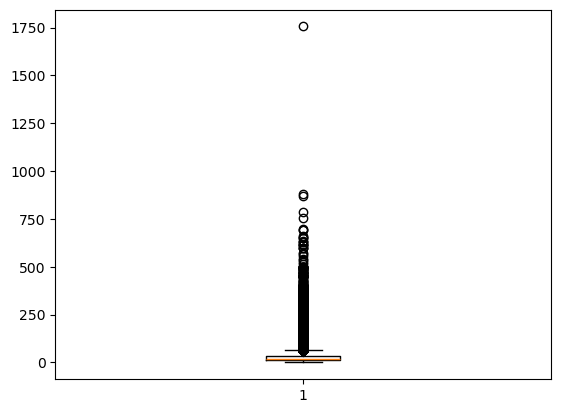

In [32]:
plt.boxplot(df['fare_amount'])

In [33]:
for col in ['fare_amount','trip_distance','duration']:
    q1=df[col].quantile(0.25)
    q3=df[col].quantile(0.75)
    IQR=q3-q1
    lower_bound=q1-1.5*IQR
    upper_bound=q3+1.5*IQR
    df=df[(df[col]>=lower_bound)& (df[col]<=upper_bound)]

In [34]:
df

,passenger_count,payment_type,fare_amount,trip_distance,duration
0,1,Cash,35.9,7.51,27.816667
1,1,Card,27.5,6.14,22.700000
2,1,Card,19.1,2.40,19.950000
5,1,Card,28.9,5.89,25.333333
6,1,Card,9.3,1.60,6.650000
...,...,...,...,...,...
3135455,1,Card,50.0,4.30,19.900000
3135459,1,Cash,24.7,5.60,21.666667
3135461,1,Cash,10.0,1.89,6.233333
3135462,1,Card,19.8,3.15,17.566667


## Exploratory Data Analysis (EDA)

With clean data in hand, the next step is to visually compare Card vs Cash across the two key numeric variables — fare amount and trip distance.

###  Distribution of Fare Amount by Payment Type

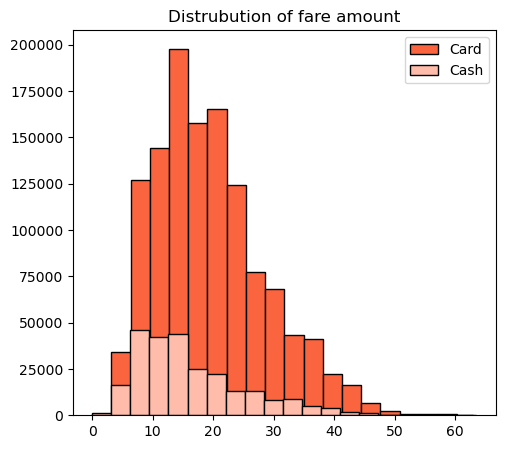

In [35]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.title('Distrubution of fare amount')
plt.hist(df[df['payment_type'] == 'Card']['fare_amount'], histtype='barstacked', bins=20, edgecolor='k', color='#FA643F', label='Card')
plt.hist(df[df['payment_type'] == 'Cash']['fare_amount'], histtype='barstacked', bins=20, edgecolor='k', color='#FFBCAB', label='Cash')
plt.legend()
plt.show()

**Observation:** Both distributions are **right-skewed** (most fares are low, with a long tail toward higher fares) — this visual is also the first clue that the data is *not normally distributed*, which becomes important later when choosing a statistical test. The Card distribution sits visibly higher than Cash across almost every fare bracket, especially in the \$15–\$30 range.

### Distribution of Trip Distance by Payment Type

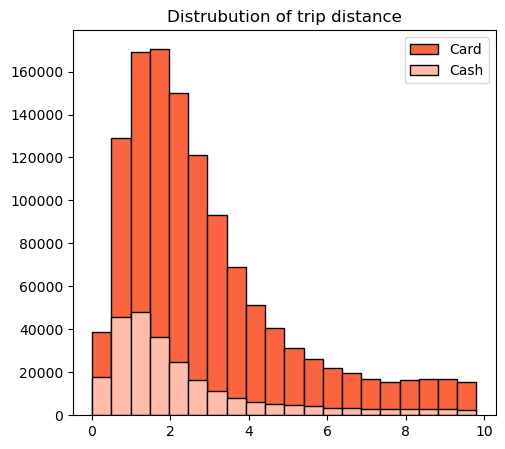

In [36]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.title('Distrubution of trip distance')
plt.hist(df[df['payment_type'] == 'Card']['trip_distance'], histtype='barstacked', bins=20, edgecolor='k', color='#FA643F', label='Card')
plt.hist(df[df['payment_type'] == 'Cash']['trip_distance'], histtype='barstacked', bins=20, edgecolor='k', color='#FFBCAB', label='Cash')
plt.legend()
plt.show()

**Observation:** Same pattern — Card trips consistently outnumber Cash trips at every distance, and the gap widens as trip distance increases past ~3 miles. This is an early signal that **longer trips lean more toward card payment**.

###  Descriptive Statistics — Card vs Cash

In [37]:
df.groupby('payment_type').agg({'fare_amount':['mean','std'],'trip_distance':['mean','std']})

fare_amount           trip_distance          
                    mean       std          mean       std
payment_type                                              
Card           19.440197  9.195904      2.935638  2.157426
Cash           16.349737  9.111374      2.411701  2.140961

##  Overall Payment Preference

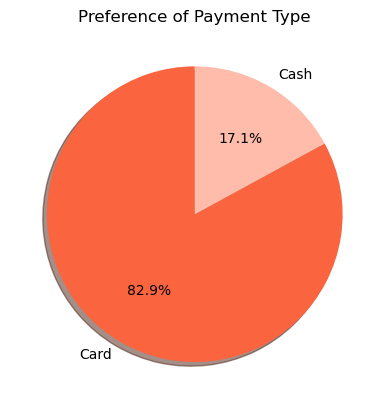

In [38]:
plt.title('Preference of Payment Type')
plt.pie(
    df['payment_type'].value_counts(normalize=True),
    labels=df['payment_type'].value_counts().index,
    startangle=90,
    shadow=True,
    autopct='%1.1f%%',
    colors=['#FA643F', '#FFBCAB']
)
plt.show()

**Result:** **82.9%** of trips in the cleaned dataset are paid by **Card**, versus only **17.1%** by **Cash**. Card is already the dominant payment method — the business question is whether it's also the more *profitable* one per trip, which the t-test below will confirm statistically.

###  Does Passenger Count Affect Payment Choice?

Building a breakdown of payment type by passenger count, first as raw counts, then converted to a percentage of the *overall* dataset so Card and Cash can be compared on the same scale.

In [39]:
df.groupby(['payment_type','passenger_count'])[['passenger_count']].count()

passenger_count
payment_type passenger_count                 
Card         1                         910778
             2                         220282
             3                          57222
             4                          33778
             5                           6127
             6                           3525
Cash         1                         194617
             2                          40713
             3                           9618
             4                           7047
             5                            871
             6                            516

In [40]:
passenger_count = df.groupby(['payment_type', 'passenger_count'])[['passenger_count']].count()
passenger_count.rename(columns={'passenger_count': 'count'}, inplace=True)
passenger_count.reset_index(inplace=True)

In [41]:
passenger_count['perc'] = (passenger_count['count'] / passenger_count['count'].sum()) * 100

In [42]:
passenger_count

,payment_type,passenger_count,count,perc
0,Card,1,910778,61.327970
1,Card,2,220282,14.832866
2,Card,3,57222,3.853089
3,Card,4,33778,2.274469
4,Card,5,6127,0.412566
5,Card,6,3525,0.237359
6,Cash,1,194617,13.104692
7,Cash,2,40713,2.741443
8,Cash,3,9618,0.647636
9,Cash,4,7047,0.474515


In [43]:
df_pivot = passenger_count.pivot(index='payment_type', columns='passenger_count', values='perc').reset_index()

In [44]:
df_pivot.columns.name = None
df_pivot

,payment_type,1,2,3,4,5,6
0,Card,61.327970,14.832866,3.853089,2.274469,0.412566,0.237359
1,Cash,13.104692,2.741443,0.647636,0.474515,0.058649,0.034745


###  Passenger Count by Payment Type

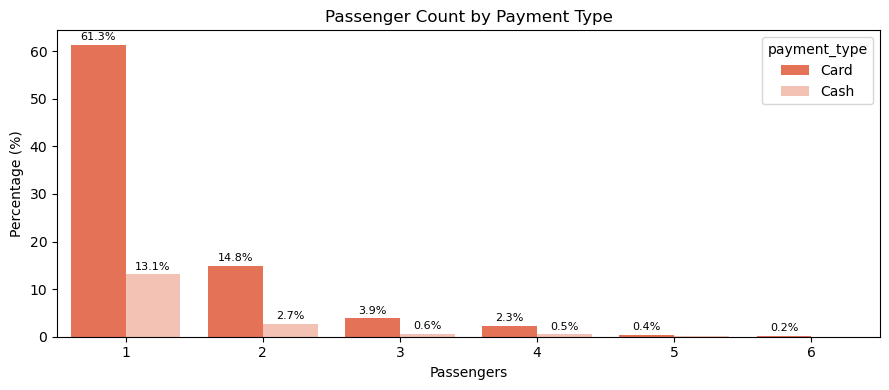

In [45]:
import seaborn as sns
plt.figure(figsize=(9, 4))
ax = sns.barplot(data=passenger_count, x='passenger_count', y='perc', hue='payment_type', palette=['#FA643F', '#FFBCAB'])

for p in ax.patches:
    if p.get_height() > 0.1:
        ax.annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2, p.get_height() + 1), ha='center', fontsize=8)

plt.title('Passenger Count by Payment Type')
plt.xlabel('Passengers')
plt.ylabel('Percentage (%)')
plt.tight_layout()
plt.show()

**Key Takeaways from the Visualization**

- **Card is king across all group sizes:** Card payments dominate heavily over cash regardless of passenger count (e.g., solo trips: 61.3% Card vs. 13.1% Cash).
- **Solo rides represent the bulk of revenue potential:** Single riders using cards account for over 61% of all taxi trips, making them the primary customer segment.
- **Proportions remain consistent:** As party size increases (2 to 6 passengers), the ratio between card and cash stays heavily tilted toward card (roughly 4:1 to 5:1 across all buckets).
- **High-capacity rides are negligible:** 5- and 6-passenger trips account for under 1% of total rides combined.

**Conclusion:** Passenger count does **not** meaningfully change payment preference — Card is preferred at roughly the same ratio no matter how many people are in the cab. This rules out group size as a confounding factor for the fare comparison, which strengthens the case for testing payment type directly against fare amount.

##  Statistical Hypothesis Testing

The EDA above shows Card fares *look* higher on average. But is that difference real, or could it just be random noise from sampling? A formal hypothesis test is needed to prove it statistically rather than relying on eyeballing a chart.

**Null Hypothesis ($H_0$):** There is no difference in average fare between customers who use credit cards and customers who use cash.

**Alternative Hypothesis ($H_a$):** There is a difference in average fare between customers who use credit cards and customers who use ca

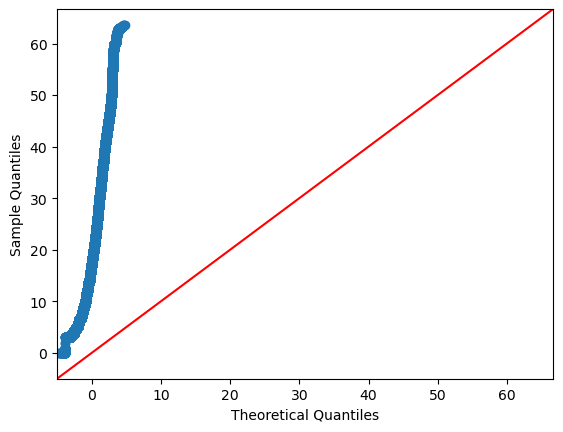

In [46]:
sm.qqplot(df['fare_amount'],line='45')
plt.show()

### 15.2 Test Selection Rationale

1. **Normality Assessment:** Q-Q plots and the distribution histograms confirm the fare metrics are right-skewed and non-normal.
2. **Central Limit Theorem & Large-Sample Validity:** Because the sample size is very large (**N > 1.4 million**), the sampling distribution of the *mean* still converges to normal by the Central Limit Theorem — so a two-sample mean comparison is still statistically valid even though the raw data isn't normal.
3. **Unequal Variance Adjustment:** Card and Cash have different group sizes and slightly different standard deviations (9.20 vs 9.11), so equal variance can't be assumed. **Welch's Independent Two-Sample T-test** (`equal_var=False`) is used specifically because it doesn't require equal variances between groups — a safer, more robust default than the standard Student's t-test.

In [47]:
card_sample=df[df['payment_type']=='Card']['fare_amount']
cash_sample=df[df['payment_type']=='Cash']['fare_amount']

In [48]:
t_stats,p_value=st.ttest_ind(a=card_sample,b=cash_sample,equal_var=False)
print('T statistic',t_stats,'p_value',p_value)

T statistic 155.24410648830388 p_value 0.0


*Computational Output**

- **Welch T-statistic:** 155.24
- **Observed P-value:** 0.000 (p < 0.05)
- **Statistical Decision:** Reject $H_0$.

### Conclusion

Since the p-value is far below the 0.05 significance threshold, the null hypothesis is rejected. This **statistically confirms** — not just visually suggests — that credit card riders generate significantly higher metered fares than cash riders, by an average of **+\$3.09 per completed trip**. Given the sample size (over 1.4 million trips), this result is highly reliable and not a fluke of random sampling.


##  Business Recommendations & Stakeholder Impact

Based on the statistical evidence above, the following recommendations are proposed to help drivers and the platform maximize revenue:

### 1. Digital Payment Incentives
Actively encourage riders to pay by card — e.g., small in-app discounts, loyalty points, or promotional pricing for card transactions — since card payments are statistically tied to a **+\$3.09 average fare uplift** and longer trip distances (+0.53 mi on average).

### 2. Target the Cash-to-Card Conversion Segment
Roughly 17% of trips are still paid in cash. Converting even a portion of this segment to card, using targeted nudges at trip completion (e.g., "pay by card next time and save $X"), could meaningfully lift average revenue per trip platform-wide.

### 3. Seamless & Secure Card Infrastructure
Ensure the in-cab and in-app card payment experience is fast, reliable, and secure — friction or trust concerns at checkout are one of the most common reasons riders default to cash, even when card is available.

### 4. No Need to Target by Group Size
The passenger-count analysis (Section 14.6) showed payment preference is consistent across group sizes — incentive campaigns don't need to be tailored differently for solo riders vs. groups, simplifying rollout.